# AMDF: các vòng H24–H26 và mục tiêu từng file ≤2%

Notebook này tính lại từ WAV train local, không chỉ đọc bảng kết quả. Giữ các notebook gốc. AMDF đo hiệu số theo độ trễ; F0 là tần số cơ bản. V/UV/SIL là hữu thanh/vô thanh/khoảng lặng. Average MAPE của mỗi file là trung bình ba lỗi phần trăm F0mean, F0std và F0num. Mục tiêu là **mỗi file ≤2%**, không chỉ trung bình bốn file.

H24 giữ quyết định V/UV ở25ms nhưng lấy ứng viên F0 ở40ms cùng tâm; H25 thử Logistic Regression hai đặc trưng; H26 thêm ACF_score đo tính tuần hoàn. Cấu hình có thể khác25ms; grid25/10 ở đây là lưới chấm chung để so sánh count. LAB chỉ có thống kê file và loại đoạn, không cao độ chuẩn từng thời điểm.


In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
REPO = Path('C:\\Users\\LAPTOP T&T\\VIOLETTA\\Documents\\ChatGPT\\XLTN\\XLTN-BT2')
HERE = REPO / 'research_workbench_2026_10_07'
sys.path.insert(0,str(HERE))
import amdf_dual_window as dual
import amdf_logistic as logistic
import amdf_joint_periodicity as joint
core, audit = joint.core, joint.audit
items = core.load_training()
config = json.loads((core.RESULTS/'frozen_config.json').read_text())['models']['AMDF_energy']['config']
print('Train local:',core.TRAIN)
print('Không đọc WAV test; mọi fit LOFO loại file đang chấm.')
display(pd.DataFrame([{'file':x['file'],'fs':x['fs'],**x['stats']} for x in items]))


Train local: C:\Users\LAPTOP T&T\VIOLETTA\Documents\ChatGPT\XLTN\XLTN-BT2\TinHieuHuanLuyen
Không đọc WAV test; mọi fit LOFO loại file đang chấm.


file,fs,F0mean,F0std,F0num
phone_F1.wav,16000,215.6,20.6,148.0
phone_M1.wav,16000,123.7,16.8,232.0
studio_F1.wav,44100,229.6,36.8,127.0
studio_M1.wav,44100,116.9,26.4,82.0


## Tính lại cấu hình cố định trên file giữ riêng

LOFO giữ một file để chấm và fit bằng ba file còn lại. Bảng dưới so cấu hình cố định đã đăng ký; không được chọn cấu hình tốt nhất cho chính held file sau khi nhìn kết quả. Việc đã nghiên cứu nhiều lần trên bốn file vẫn giới hạn tính độc lập.

Logistic Regression là bộ phân loại tuyến tính trên các đặc trưng đã chuẩn hóa; C điều khiển regularization. Hai đặc trưng là AMDF_score và relativeRMS. Nhánh ba đặc trưng thêm ACF_score, vẫn dùng AMDF cho các ứng viên F0. Cổng năng lượng, ngưỡng xác suất0.5 và đường chọn cao độ giữ như registry.


In [2]:
features = {}
for item in items:
    _, audio = core.load_audio(core.TRAIN/item['file'])
    features[item['file']] = dual.extract(item,audio,dual.registry('H24')[1])
methods = [('AMDF25','H24','amdf_f25_h10',None,None),
           ('AMDF40','H24','amdf_gate25_pitch40',dual,dual.registry('H24')[1])]
methods += [(f'AMDF_LR{option["C"]:g}','H25',option['id'],logistic,option) for option in logistic.registry('H25')[1:]]
methods += [('AMDF_ACF_LR','H26','amdf_lr1_3d_acf',joint,joint.registry('H26')[2])]
rows = []
columns = ['F0mean','F0std','F0num','average_mape','macro_f1','recall_v','false_voiced_sil']
for name,family,identity,module,option in methods:
    for held in items:
        pool = [x for x in items if x['file']!=held['file']]
        if module is None:
            pred,f0 = core.infer(held,config,core.fit(pool,config))
        else:
            training = [features[x['file']] for x in pool]
            pred,f0,_,_ = module.infer(features[held['file']],training,option,config)
        measured = core.score_file(held,pred,f0)
        saved = pd.read_csv(HERE/f'results/{family}_fixed_lofo.csv')
        reference = saved[(saved.option_id==identity)&(saved.file==held['file'])].iloc[0]
        assert np.allclose([measured[k] for k in columns],reference[columns].astype(float),atol=1e-8)
        rows.append({'method':name,'family':family,'option_id':identity,**measured})
table = pd.DataFrame(rows)
table.to_csv(HERE/'results/AMDF_target_notebook_per_file.csv',index=False)
assert len(table)==24 and not table.duplicated(['method','file']).any()
display(table[['method','file','average_mape','F0mean_mape','F0std_mape','F0num_mape','recall_v','false_voiced_sil']])
print('PASS: 24 rows recomputed from train WAV and independent fits, saved measurements match1e-8.')


PASS: 24 rows recomputed from train WAV and independent fits, saved measurements match1e-8.


method,file,average_mape,F0mean_mape,F0std_mape,F0num_mape,recall_v,false_voiced_sil
AMDF25,phone_F1.wav,13.303347,0.241334,36.290329,3.378378,0.908497,1
AMDF25,phone_M1.wav,5.003046,0.389107,4.706237,9.913793,0.831967,0
AMDF25,studio_F1.wav,4.346475,0.363738,3.226869,9.448819,0.934959,0
AMDF25,studio_M1.wav,4.417638,1.176528,7.198337,4.878049,0.829787,0
AMDF40,phone_F1.wav,8.899895,1.007605,22.313703,3.378378,0.908497,1
AMDF40,phone_M1.wav,4.358372,0.257548,2.903775,9.913793,0.831967,0
AMDF40,studio_F1.wav,4.545606,0.611076,3.576924,9.448819,0.934959,0
AMDF40,studio_M1.wav,5.082710,1.327077,9.043005,4.878049,0.829787,0
AMDF_LR0.1,phone_F1.wav,10.857992,0.772596,23.693273,8.108108,0.882353,1
AMDF_LR0.1,phone_M1.wav,4.966056,0.167151,2.231018,12.500000,0.819672,0


## Thành phần nào đang cản mục tiêu?

Mỗi thanh là Average MAPE, tách ba phần đóng góp mean/std/count (mỗi lỗi chia3). Đường2% là mục tiêu. Các nhánh giữ count không đổi không thể tự xử lý phần lỗi count; không cắt hoặc thêm khung dự đoán theo số GT của held file. H26 có cải thiện ở studio nhưng xấu ở phone_F1; giữ cả thất bại để đối chiếu.


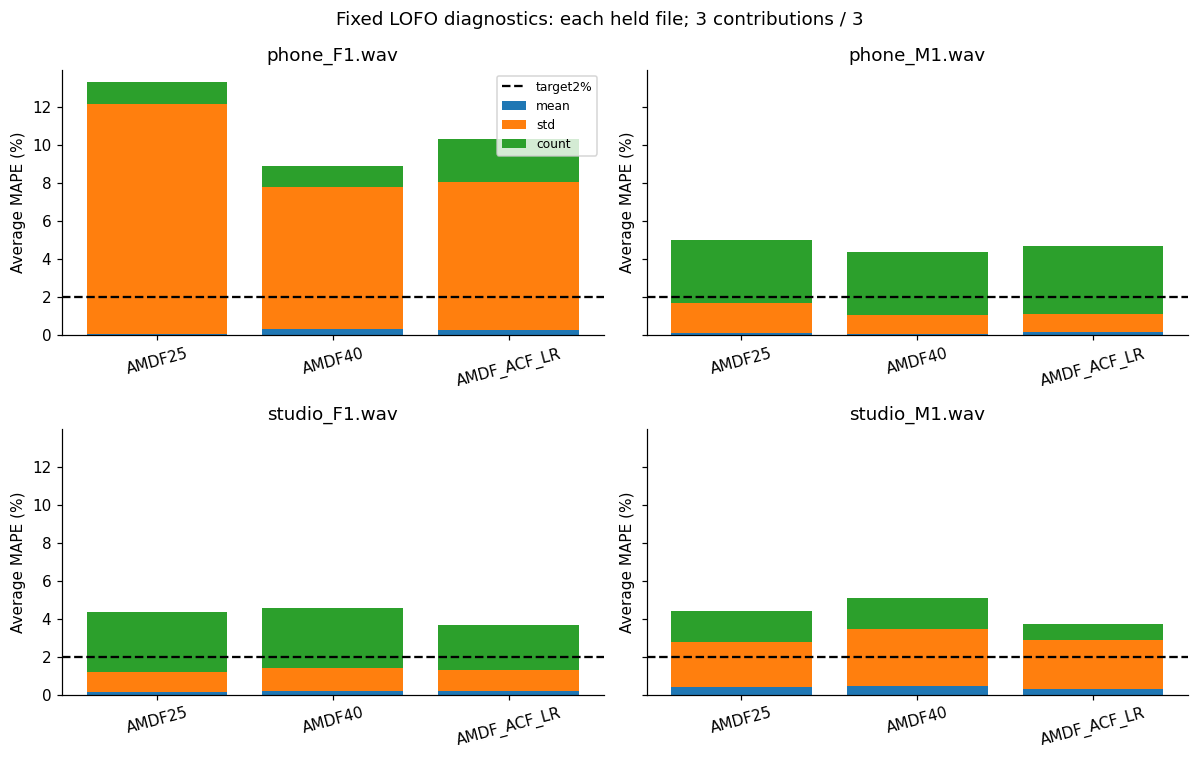

In [3]:
audit.ARTIFACTS.clear()
fig, axes = audit.plt.subplots(2,2,figsize=(11,7),sharey=True)
names = ['AMDF25','AMDF40','AMDF_ACF_LR']
for ax,(file,group) in zip(axes.flat,table.groupby('file')):
    group = group.set_index('method').loc[names]
    bottom = np.zeros(len(names))
    for metric,label in [('F0mean_mape','mean'),('F0std_mape','std'),('F0num_mape','count')]:
        values = group[metric].to_numpy()/3
        ax.bar(names,values,bottom=bottom,label=label)
        bottom += values
    assert np.allclose(bottom,group.average_mape)
    ax.axhline(2,color='black',linestyle='--',label='target2%')
    ax.set(title=file,ylabel='Average MAPE (%)')
    ax.tick_params(axis='x',rotation=15)
axes[0,0].legend(fontsize=8)
fig.suptitle('Fixed LOFO diagnostics: each held file; 3 contributions / 3')
audit.save_figure('AMDF_target_components',fig,[HERE/'results/AMDF_target_notebook_per_file.csv'],
    'Tính lại từ WAV train; so ba cấu hình cố định, không chọn best theo held.',
    'File-stat metrics không xác minh F0 từng thời điểm; n4 và lịch sử nghiên cứu.')
for artifact in audit.ARTIFACTS:
    artifact.update(generator='build_amdf_target_notebook.py',generator_sha256=audit.digest(HERE/'build_amdf_target_notebook.py'),
                    command='python research_workbench_2026_10_07/execute_amdf_target_notebook.py')
audit.json_write(HERE/'results/AMDF_target_notebook_figure_manifest.json',{'figures':audit.ARTIFACTS})
display(fig)
audit.plt.close(fig)


## Kết quả quy trình chọn cấu hình và việc đạt mục tiêu

Nested LOFO: outer file bị loại khỏi mọi bước fit và chọn cấu hình; inner folds chọn bằng các file còn lại. H24 rank mean đã đăng ký trước; H25/H26 rank file tệ nhất theo yêu cầu đã làm rõ. Các quy trình khác nhau, không gộp thành một metric của cấu hình chung. Registry còn được định hướng bởi lịch sử đã xem bốn file nên các kết quả là exploratory.

Không file nào được gọi là đạt bằng cách lấy best configuration theo chính file đó. Mục tiêu cần cả bốn kết quả giữ riêng ≤2%, cùng nhánh đánh giá đã chốt. Paper review và nhánh referencepipeline mới xem LITERATURE_REVIEW.md.


In [4]:
nested_rows = []
for family in ('H24','H25','H26'):
    result = json.loads((HERE/f'results/{family}_experiment.json').read_text())
    for relative,expected in result['code_sha256'].items():
        assert hashlib.sha256((REPO/relative).read_bytes()).hexdigest()==expected
    nested = pd.read_csv(HERE/f'results/{family}_metrics.csv')
    selected = nested[(nested.split=='nested')&(nested.model=='candidate')]
    assert len(selected)==4
    nested_rows += [{'family':family,**row} for row in selected.to_dict('records')]
nested_table = pd.DataFrame(nested_rows)
display(nested_table[['family','file','option_id','average_mape','F0std_mape','F0num_mape']])
status = nested_table.groupby('family').average_mape.agg(mean='mean',worst='max',all_files_le_2=lambda x:bool((x<=2).all())).reset_index()
display(status)
status.to_csv(HERE/'results/AMDF_target_notebook_status.csv',index=False)
print('Trạng thái thực:', 'đạt' if status.all_files_le_2.any() else 'chưa đạt mỗi file≤2%')


Trạng thái thực: chưa đạt mỗi file≤2%


family,file,option_id,average_mape,F0std_mape,F0num_mape
H24,phone_F1.wav,amdf_gate25_pitch40,8.899895,22.313703,3.378378
H24,phone_M1.wav,amdf_gate25_pitch40,4.358372,2.903775,9.913793
H24,studio_F1.wav,amdf_f25_h10,4.346475,3.226869,9.448819
H24,studio_M1.wav,amdf_gate25_pitch40,5.082710,9.043005,4.878049
H25,phone_F1.wav,amdf_lr10,9.856045,23.454459,5.405405
H25,phone_M1.wav,amdf_control,4.358372,2.903775,9.913793
H25,studio_F1.wav,amdf_control,4.545606,3.576924,9.448819
H25,studio_M1.wav,amdf_lr1,3.756524,9.578790,0.000000
H26,phone_F1.wav,amdf_lr1_2d,9.856045,23.454459,5.405405
H26,phone_M1.wav,amdf_lr1_3d_acf,4.689213,2.767981,10.775862


family,mean,worst,all_files_le_2
H24,5.671863,8.899895,False
H25,5.629137,9.856045,False
H26,5.478347,9.856045,False
